# EpiCite · Notebook 06 — Evaluation Suite

**Group 12 — AIT NLP** · Biraj Koirala · Longfei Shi

---

## What this notebook covers

This notebook consumes the artefacts produced by Notebook 05 and runs the
complete evaluation programme designed in our planning conversation. Nothing
in this notebook trains a model — it only loads checkpoints and analyses them.

| Section | Topic | Decision |
|---|---|---|
| A | Setup & load checkpoints | — |
| B | Feature ranking via triangulation (SHAP + permutation + MI) | Q1, Q5 track 1 |
| C | Sentence-level explanations (IG + LIME side-by-side) | Q5 track 2 |
| D | Stage 1 → Stage 2 information-flow ablation | Q5 track 3 |
| E | Class-conditional SHAP | Q5 track 4 |
| F | Calibration analysis (reliability + ECE) | Q5 track 5 |
| G | Error analysis: typology + stratified + cascade + noise | Q7 |
| H | Qwen-0.5B benchmark (zero-shot + few-shot) | Q8 |
| I | Use case 1 — Wikipedia article audit | Q6 |
| J | Use case 2 — MCP demo walkthrough | Q6 |

The headline plots and tables for the report all come from this notebook.


---
## Section A · Setup & Load Checkpoints


In [1]:
# !pip install -q shap captum lime sentencepiece
import os, json, pickle, time, math, warnings, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    DistilBertTokenizerFast, DistilBertModel,
    DistilBertForSequenceClassification,
)

from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score, accuracy_score,
    confusion_matrix, brier_score_loss, average_precision_score,
    cohen_kappa_score, precision_recall_curve,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [2]:
# Load the metadata Notebook 05 wrote
with open("output/stage2v3_metadata.json") as f:
    META = json.load(f)

CLASSES   = ["Claim", "Evidence", "Opinion", "Background"]
LABEL2ID  = {c: i for i, c in enumerate(CLASSES)}
ID2LABEL  = {i: c for c, i in LABEL2ID.items()}
NUM_CLASSES = len(CLASSES)
MODEL_NAME = "distilbert-base-uncased"

ENG_COLS_FULL     = META["stage2"]["feature_cols_full"]
ENG_COLS_BASELINE = META["stage2"]["feature_cols_baseline"]
ENG_COLS_NO_EPI   = META["stage2"]["feature_cols_no_epi"]
print(f"Full feature dims    : {len(ENG_COLS_FULL)}")
print(f"Baseline feature dims: {len(ENG_COLS_BASELINE)}")
print(f"No-epi feature dims  : {len(ENG_COLS_NO_EPI)}")
print()
print("Stage 2 results from Notebook 05:")
for k, v in META["stage2"]["results"].items():
    print(f"  {k:<10}: AUC={v['auc']:.4f}  F1={v['f1']:.4f}  Brier={v['brier']:.4f}")

Full feature dims    : 34
Baseline feature dims: 17
No-epi feature dims  : 29

Stage 2 results from Notebook 05:
  full      : AUC=0.7270  F1=0.6548  Brier=0.2353
  no_epi    : AUC=0.7365  F1=0.6617  Brier=0.2133


In [3]:
# ── Re-define the LateFusionCitationScorer so we can load checkpoints ──
class LateFusionCitationScorer(nn.Module):
    def __init__(self, distilbert, num_eng_features: int, dropout: float = 0.3):
        super().__init__()
        self.distilbert = distilbert
        self.cls_dim    = distilbert.config.hidden_size
        self.eng_dim    = num_eng_features
        fused_dim       = self.cls_dim + self.eng_dim
        self.head = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, 256), nn.GELU(), nn.Dropout(dropout),
            nn.LayerNorm(256),
            nn.Linear(256, 64),         nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
    def forward(self, input_ids, attention_mask, eng_features):
        out = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        fused = torch.cat([cls, eng_features], dim=-1)
        return torch.sigmoid(self.head(fused)).squeeze(-1)
    def get_cls_embedding(self, input_ids, attention_mask):
        out = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]

def load_lf_model(ckpt_path, num_eng_features):
    distilbert = DistilBertModel.from_pretrained(MODEL_NAME)
    model = LateFusionCitationScorer(distilbert, num_eng_features=num_eng_features).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    return model

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

print("Loading models...")
model_full     = load_lf_model(META["stage2"]["full_ckpt"],     len(ENG_COLS_FULL))
print("✓ Full v3 loaded")

# Baseline-18 variant is OPTIONAL — only load if its checkpoint exists.
# (Decision in conversation: skip 2.8 if time-constrained.)
HAS_BASELINE = Path(META["stage2"]["baseline_ckpt"]).exists()
if HAS_BASELINE:
    model_baseline = load_lf_model(META["stage2"]["baseline_ckpt"], len(ENG_COLS_BASELINE))
    print("✓ Baseline-18 loaded")
else:
    model_baseline = None
    print("⊘ Baseline-18 checkpoint missing — skipping that variant")

# No-epi variant is also optional but you trained it; load if present.
HAS_NO_EPI = Path(META["stage2"]["no_epi_ckpt"]).exists()
if HAS_NO_EPI:
    model_no_epi = load_lf_model(META["stage2"]["no_epi_ckpt"], len(ENG_COLS_NO_EPI))
    print("✓ No-epi loaded")
else:
    model_no_epi = None
    print("⊘ No-epi checkpoint missing — skipping that variant")

s1_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES, id2label=ID2LABEL, label2id=LABEL2ID,
).to(DEVICE)
s1_model.load_state_dict(torch.load(META["stage1"]["checkpoint"], map_location=DEVICE))
s1_model.eval()
print("✓ Stage 1 v3 loaded")

Loading models...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Full v3 loaded
⊘ Baseline-18 checkpoint missing — skipping that variant


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ No-epi loaded


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Stage 1 v3 loaded


In [4]:
# Load test predictions and feature matrix
pred_df  = pd.read_csv(META["stage2"]["test_preds"])
feat_all = pd.read_csv(META["stage2"]["engineered_features"])
print(f"Stage 2 test predictions : {len(pred_df):,} rows × {len(pred_df.columns)} cols")
print(f"Engineered feature matrix : {len(feat_all):,} rows × {len(feat_all.columns)} cols")

# Stage 1 predictions
s1_test_df = pd.read_csv(META["stage1"]["test_preds"])
print(f"Stage 1 test predictions  : {len(s1_test_df):,} rows")
ibm_pred_path = META["stage1"]["ibm_test_preds"]
if Path(ibm_pred_path).exists():
    s1_ibm_df = pd.read_csv(ibm_pred_path)
    print(f"Stage 1 IBM test preds    : {len(s1_ibm_df):,} rows")
else:
    s1_ibm_df = None

Stage 2 test predictions : 991 rows × 12 cols
Engineered feature matrix : 151,981 rows × 34 cols
Stage 1 test predictions  : 3,531 rows
Stage 1 IBM test preds    : 878 rows


---
## Section B · Feature Ranking via Triangulation (Q1, Q5 track 1)

We rank the engineered features using three independent methods. When all three
agree on the top features, the finding is robust enough to put in the report.
The headline number is **the Borda-count rank** across methods — features
ranked highly by all three end up at the top.

- **SHAP** — Shapley values from a random sample of test predictions
- **Permutation importance** — shuffle one feature, measure AUC drop
- **Mutual information** — model-agnostic, dependence between feature and label


### B.1 · Build the test-set feature matrix

In [5]:
# Get engineered features for the test split only
# wiki_df is reconstructed from the prediction CSV's row order
test_mask = pred_df.index  # The CSV is already test-only
# Re-extract engineered values for these test rows from feat_all
# (feat_all has ALL splits; we need only test). The prediction CSV preserves
# row order, so we use the same boolean mask used in Notebook 05.
# Easiest: re-build from saved metadata
print("Recomputing test-mask alignment from the WikiSQE source...")
from datasets import load_dataset
wiki_ds = load_dataset("ando55/WikiSQE_experiment", name="citation needed")

def hf_to_df(split, name):
    df = split.to_pandas().rename(columns={"text": "sentence"})
    df["split"] = name
    df = df.dropna(subset=["sentence"])
    df = df[df["sentence"].str.split().str.len().between(5, 80)]
    df["label"] = df["label"].astype(int)
    return df[["sentence","label","split"]].reset_index(drop=True)

# Match the same subsampling Notebook 05 did
SEED = META["config"]["seed"]
T = META["config"]["wikisqe_target_per_class"]
train_w = hf_to_df(wiki_ds["train"], "train")
pos = train_w[train_w["label"]==1].sample(min(T, (train_w["label"]==1).sum()), random_state=SEED)
neg = train_w[train_w["label"]==0].sample(min(T, (train_w["label"]==0).sum()), random_state=SEED)
train_w = pd.concat([pos, neg], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_w   = hf_to_df(wiki_ds["val"],   "val")
test_w  = hf_to_df(wiki_ds["test"],  "test")
wiki_df = pd.concat([train_w, val_w, test_w], ignore_index=True)
test_idx = (wiki_df["split"] == "test").values
print(f"Test rows: {test_idx.sum():,}  (matches pred_df: {len(pred_df):,})")
assert test_idx.sum() == len(pred_df), "Row count mismatch — re-run Notebook 05?"

X_test = feat_all.loc[test_idx, ENG_COLS_FULL].reset_index(drop=True).values.astype(np.float32)
y_test = pred_df["label"].values
print(f"X_test shape: {X_test.shape}")

Recomputing test-mask alignment from the WikiSQE source...
Test rows: 991  (matches pred_df: 991)
X_test shape: (991, 34)


### B.2 · Method 1 — SHAP

SHAP background sample: 200 random test rows. Explain a sample of 1000 to keep
runtime manageable. The wrapper holds [CLS] fixed per row and varies the
engineered features only.


In [6]:
import shap
from torch.utils.data import DataLoader

# ── Pre-compute [CLS] embeddings for the test set (cached) ────────
CLS_CACHE = Path("output/stage2v3_test_cls_embeddings.npy")
if CLS_CACHE.exists():
    test_cls = np.load(CLS_CACHE)
    print(f"Loaded cached CLS embeddings: {test_cls.shape}")
else:
    class _InfDS(Dataset):
        def __init__(self, sents): self.sents = list(sents)
        def __len__(self):  return len(self.sents)
        def __getitem__(self, i):
            enc = tokenizer(self.sents[i], max_length=128, padding="max_length",
                            truncation=True, return_tensors="pt")
            return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)
    sentences_test = pred_df["sentence"].tolist()
    loader = DataLoader(_InfDS(sentences_test), batch_size=64)
    cls_chunks = []
    with torch.no_grad():
        for ids, mask in tqdm(loader, desc="CLS embeddings"):
            out = model_full.distilbert(input_ids=ids.to(DEVICE),
                                         attention_mask=mask.to(DEVICE))
            cls_chunks.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    test_cls = np.concatenate(cls_chunks)
    np.save(CLS_CACHE, test_cls)
    print(f"Saved → {CLS_CACHE}: {test_cls.shape}")

Loaded cached CLS embeddings: (991, 768)


In [7]:
# ── SHAP wrapper: fixed [CLS], variable engineered features ───────
N_BG     = min(200,  len(X_test))      # was 200; capped to test-set size
N_EXPL   = min(1000, len(X_test))      # was 1000; capped to test-set size
rng = np.random.default_rng(SEED)
bg_idx   = rng.choice(len(X_test), N_BG,   replace=False)
expl_idx = rng.choice(len(X_test), N_EXPL, replace=False)

bg_X    = X_test[bg_idx]
bg_cls  = test_cls[bg_idx]
expl_X  = X_test[expl_idx]
expl_cls= test_cls[expl_idx]

def predict_with_features(X, cls_pool):
    """Closure over a fixed CLS pool — randomly assigns CLS rows to feature rows.

    For SHAP global importance this is the standard trick: break the dependency
    between CLS and engineered features so SHAP isolates the engineered-feature
    contribution to the score.
    """
    def _pred(features):
        # features: (N, F) numpy
        n = features.shape[0]
        # repeat cls_pool to match n
        cls_idx = rng.integers(0, len(cls_pool), n)
        cls_b = cls_pool[cls_idx]
        with torch.no_grad():
            cls_t  = torch.tensor(cls_b,    dtype=torch.float32, device=DEVICE)
            feat_t = torch.tensor(features, dtype=torch.float32, device=DEVICE)
            fused  = torch.cat([cls_t, feat_t], dim=-1)
            scores = model_full.head(fused).squeeze(-1)
            return torch.sigmoid(scores).cpu().numpy()
    return _pred

predict_fn = predict_with_features(expl_X, test_cls)
print(f"SHAP setup: background={N_BG}, explain={N_EXPL}, features={X_test.shape[1]}")

SHAP setup: background=200, explain=991, features=34


In [8]:
print("Running SHAP KernelExplainer (this takes ~5-15 min)...")
explainer = shap.KernelExplainer(predict_fn, bg_X)
shap_values = explainer.shap_values(expl_X, nsamples=100)
np.save("output/stage2v3_shap_values.npy", shap_values)
print(f"SHAP values: {shap_values.shape}")

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Running SHAP KernelExplainer (this takes ~5-15 min)...


  0%|          | 0/991 [00:00<?, ?it/s]

SHAP values: (991, 34)


In [9]:
# Mean |SHAP| ranking
shap_abs_mean = np.abs(shap_values).mean(axis=0)
shap_rank_df = pd.DataFrame({
    "feature":  ENG_COLS_FULL,
    "shap_imp": shap_abs_mean,
}).sort_values("shap_imp", ascending=False).reset_index(drop=True)
shap_rank_df["shap_rank"] = np.arange(1, len(shap_rank_df) + 1)
print("Top 10 by SHAP:"); print(shap_rank_df.head(10).to_string(index=False))

Top 10 by SHAP:
            feature  shap_imp  shap_rank
    sentence_length  0.025562          1
          n_passive  0.011777          2
    rate_ent_person  0.011482          3
          n_numbers  0.011431          4
          n_clauses  0.011312          5
epi_prob_Background  0.011275          6
      n_vague_quant  0.011261          7
     rate_ent_total  0.011182          8
     epi_confidence  0.011104          9
      rate_ent_date  0.010959         10


### B.3 · Method 2 — Permutation Importance

Shuffle one feature column at a time, measure AUC drop on a held-out sample.
Slower than SHAP but model-agnostic and harder to game.


In [10]:
# Permutation importance — measure AUC drop when each feature is shuffled
# We use a 5,000 row sample to keep this tractable
PI_N = 5000
pi_idx = rng.choice(len(X_test), min(PI_N, len(X_test)), replace=False)
pi_X    = X_test[pi_idx]
pi_y    = y_test[pi_idx]
pi_cls  = test_cls[pi_idx]

def lf_score_full(X_features, cls_arr):
    """Score full Late-Fusion model with given engineered features and CLS rows."""
    with torch.no_grad():
        cls_t  = torch.tensor(cls_arr,    dtype=torch.float32, device=DEVICE)
        feat_t = torch.tensor(X_features, dtype=torch.float32, device=DEVICE)
        fused  = torch.cat([cls_t, feat_t], dim=-1)
        scores = torch.sigmoid(model_full.head(fused).squeeze(-1)).cpu().numpy()
    return scores

base_scores = lf_score_full(pi_X, pi_cls)
base_auc    = roc_auc_score(pi_y, base_scores)
print(f"Baseline AUC on permutation sample: {base_auc:.4f}")

perm_imps = []
for j, col in enumerate(tqdm(ENG_COLS_FULL, desc="Permutation")):
    drops = []
    for _ in range(3):  # 3 repeats for stability
        Xp = pi_X.copy()
        rng.shuffle(Xp[:, j])
        s = lf_score_full(Xp, pi_cls)
        drops.append(base_auc - roc_auc_score(pi_y, s))
    perm_imps.append(np.mean(drops))

perm_rank_df = pd.DataFrame({
    "feature":  ENG_COLS_FULL,
    "perm_imp": perm_imps,
}).sort_values("perm_imp", ascending=False).reset_index(drop=True)
perm_rank_df["perm_rank"] = np.arange(1, len(perm_rank_df) + 1)
print("\nTop 10 by permutation importance:")
print(perm_rank_df.head(10).to_string(index=False))

Baseline AUC on permutation sample: 0.7270


Permutation:   0%|          | 0/34 [00:00<?, ?it/s]


Top 10 by permutation importance:
            feature  perm_imp  perm_rank
    sentence_length  0.007228          1
     n_proper_nouns  0.001135          2
     dep_tree_depth  0.000740          3
     epi_prob_Claim  0.000559          4
epi_prob_Background  0.000207          5
       rate_ent_org  0.000192          6
        n_hedge_aux  0.000186          7
        n_hedge_adv  0.000178          8
          n_clauses  0.000128          9
      n_hedge_verbs  0.000101         10


### B.4 · Method 3 — Mutual Information

Direct nonparametric dependency between each feature and the label. Doesn't use
the model at all — provides an independent check.


In [11]:
print("Computing mutual information...")
# MI doesn't need [CLS]; uses raw features + labels
# Use a sample for speed
MI_N = 10000
mi_idx = rng.choice(len(X_test), min(MI_N, len(X_test)), replace=False)
mi_imps = mutual_info_classif(X_test[mi_idx], y_test[mi_idx],
                               discrete_features=False, random_state=SEED)

mi_rank_df = pd.DataFrame({
    "feature": ENG_COLS_FULL,
    "mi_imp":  mi_imps,
}).sort_values("mi_imp", ascending=False).reset_index(drop=True)
mi_rank_df["mi_rank"] = np.arange(1, len(mi_rank_df) + 1)
print("Top 10 by MI:"); print(mi_rank_df.head(10).to_string(index=False))

Computing mutual information...
Top 10 by MI:
             feature   mi_imp  mi_rank
          n_boosters 0.038795        1
         rate_dollar 0.026698        2
 rate_causal_markers 0.026053        3
rate_universal_quant 0.022126        4
     sentence_length 0.016257        5
         n_negations 0.015485        6
    epi_prob_Opinion 0.015182        7
     noun_verb_ratio 0.013271        8
    rate_inline_cite 0.011675        9
          rate_digit 0.010588       10


### B.5 · Triangulation: Borda Rank

Average rank across the three methods. Lower = more consistently important.
This is the headline ranking for the report.


In [12]:
tri_df = (shap_rank_df[["feature","shap_imp","shap_rank"]]
          .merge(perm_rank_df[["feature","perm_imp","perm_rank"]], on="feature")
          .merge(mi_rank_df[["feature","mi_imp","mi_rank"]],       on="feature"))
tri_df["borda_rank"] = (tri_df["shap_rank"] + tri_df["perm_rank"] + tri_df["mi_rank"]) / 3
tri_df = tri_df.sort_values("borda_rank").reset_index(drop=True)
tri_df["family"] = tri_df["feature"].apply(lambda f:
    "epistemic"     if "epi_" in f else
    "v2-numerical"  if any(k in f for k in ["percent","dollar","year","digit","inline_cite"]) else
    "v2-entity"     if "ent_" in f else
    "v2-quantifier" if any(k in f for k in ["universal_quant","superlative"]) else
    "v2-verb"       if any(k in f for k in ["reporting_verbs","causal_markers"]) else
    "v2-syntactic"  if any(k in f for k in ["dep_tree_depth","n_clauses","noun_verb_ratio"]) else
    "baseline"
)

print("=" * 100)
print(f"{'Rank':>4} {'Feature':<25} {'Family':<14} {'SHAP':>8} {'Perm':>8} {'MI':>8} {'Avg':>6}")
print("=" * 100)
for i, row in tri_df.iterrows():
    print(f"{i+1:>4} {row['feature']:<25} {row['family']:<14} "
          f"{row['shap_imp']:>8.4f} {row['perm_imp']:>8.4f} "
          f"{row['mi_imp']:>8.4f} {row['borda_rank']:>6.2f}")

tri_df.to_csv("output/feature_ranking_triangulation.csv", index=False)
print(f"\nSaved → output/feature_ranking_triangulation.csv")

Rank Feature                   Family             SHAP     Perm       MI    Avg
   1 sentence_length           baseline         0.0256   0.0072   0.0163   2.33
   2 n_clauses                 v2-syntactic     0.0113   0.0001   0.0053   9.33
   3 rate_causal_markers       v2-verb          0.0110   0.0000   0.0261   9.67
   4 n_proper_nouns            baseline         0.0109   0.0011   0.0005  11.33
   5 rate_dollar               v2-numerical     0.0105   0.0000   0.0267  11.33
   6 dep_tree_depth            v2-syntactic     0.0101   0.0007   0.0041  13.67
   7 n_subjective_pron         baseline         0.0103   0.0001   0.0074  14.00
   8 n_hedge_verbs             baseline         0.0109   0.0001   0.0000  14.00
   9 epi_confidence            epistemic        0.0111  -0.0000   0.0079  14.33
  10 n_hedge_adv               baseline         0.0102   0.0002   0.0061  14.33
  11 epi_prob_Background       epistemic        0.0113   0.0002   0.0000  15.00
  12 n_passive                 baseline 

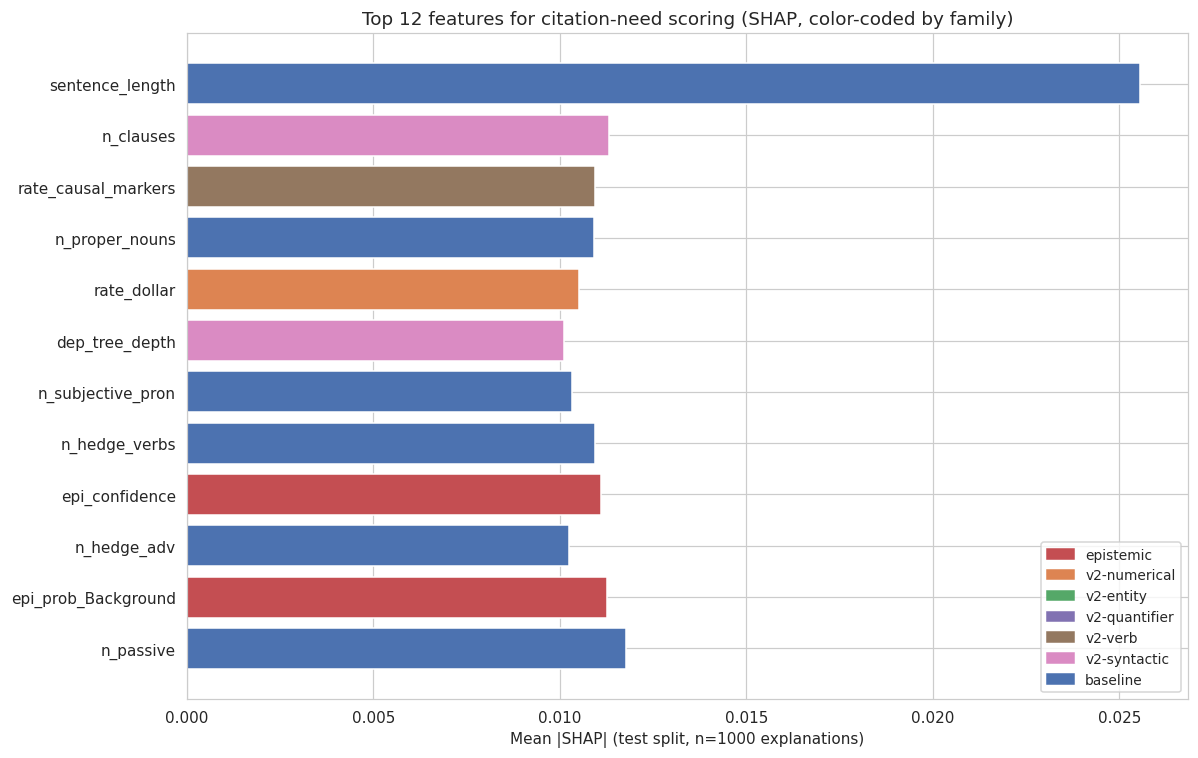

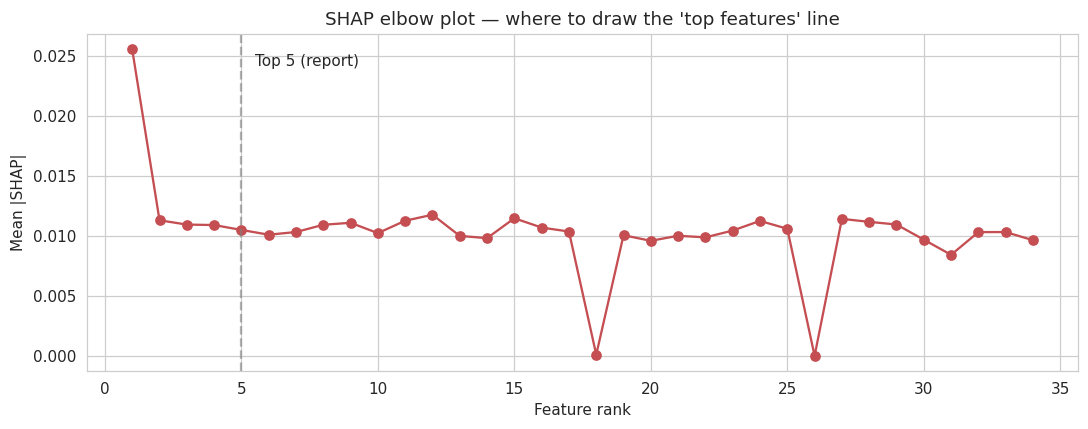


Top 5 features (the report headline):
            feature       family  borda_rank
    sentence_length     baseline    2.333333
          n_clauses v2-syntactic    9.333333
rate_causal_markers      v2-verb    9.666667
     n_proper_nouns     baseline   11.333333
        rate_dollar v2-numerical   11.333333


In [13]:
# Headline plot — top 12 features, color-coded by family
top12 = tri_df.head(12).iloc[::-1]  # reverse for horizontal bar
family_colors = {
    "epistemic":     "#C44E52",
    "v2-numerical":  "#DD8452",
    "v2-entity":     "#55A868",
    "v2-quantifier": "#8172B2",
    "v2-verb":       "#937860",
    "v2-syntactic":  "#DA8BC3",
    "baseline":      "#4C72B0",
}

fig, ax = plt.subplots(figsize=(11, 7))
colors = [family_colors[f] for f in top12["family"]]
ax.barh(top12["feature"], top12["shap_imp"], color=colors, edgecolor="white")
patches = [mpatches.Patch(color=c, label=lbl) for lbl, c in family_colors.items()]
ax.legend(handles=patches, loc="lower right", fontsize=9)
ax.set(title="Top 12 features for citation-need scoring (SHAP, color-coded by family)",
       xlabel="Mean |SHAP| (test split, n=1000 explanations)")
plt.tight_layout()
plt.savefig("output/feature_ranking_top12.png", dpi=150, bbox_inches="tight")
plt.show()

# Elbow plot — supports the "report top K" decision
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(1, len(tri_df)+1), tri_df["shap_imp"].values, "o-", color="#C44E52")
ax.set(title="SHAP elbow plot — where to draw the 'top features' line",
       xlabel="Feature rank", ylabel="Mean |SHAP|")
ax.axvline(5, linestyle="--", color="grey", alpha=0.6)
ax.text(5.5, ax.get_ylim()[1]*0.9, "Top 5 (report)", fontsize=10)
plt.tight_layout()
plt.savefig("output/feature_ranking_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 features (the report headline):")
print(tri_df.head(5)[["feature","family","borda_rank"]].to_string(index=False))

---
## Section C · Sentence-Level Explanations — IG + LIME (Q5 track 2)

For each sentence we want token-level attribution: which words drove the citation
prediction? We run two methods side-by-side so the report can compare:

- **Integrated Gradients (Captum)** — gradient-based, faithful to the model
- **LIME** — perturbation-based, model-agnostic


In [14]:
from captum.attr import IntegratedGradients, LayerIntegratedGradients

class _ScoreOnly(nn.Module):
    """Wraps the LF model so Captum sees a single scalar output per row."""
    def __init__(self, lf): super().__init__(); self.lf = lf
    def forward(self, input_ids, attention_mask, eng_features):
        return self.lf(input_ids, attention_mask, eng_features)

score_only = _ScoreOnly(model_full).to(DEVICE).eval()

# Layer IG on the embedding layer — the standard recipe for transformer IG
lig = LayerIntegratedGradients(score_only, score_only.lf.distilbert.embeddings)

def get_ig_attribution(sentence: str, eng_features: np.ndarray, target_score: float = None):
    """Return per-token IG attribution for a single sentence."""
    enc = tokenizer(sentence, max_length=128, padding="max_length",
                    truncation=True, return_tensors="pt").to(DEVICE)
    feat_t = torch.tensor(eng_features, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    # Reference: all-zero embeddings (standard baseline)
    ref_ids = torch.zeros_like(enc["input_ids"]).fill_(tokenizer.pad_token_id)
    attrs = lig.attribute(
        inputs=enc["input_ids"], baselines=ref_ids,
        additional_forward_args=(enc["attention_mask"], feat_t),
        n_steps=50, return_convergence_delta=False,
    )
    # Sum over hidden dim → per-token scalar
    attrs_token = attrs.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    # Normalise to [-1, 1]
    if np.abs(attrs_token).max() > 0:
        attrs_token = attrs_token / np.abs(attrs_token).max()
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"].squeeze(0).cpu().numpy())
    # Trim padding
    keep = [(t, a) for t, a in zip(tokens, attrs_token) if t != tokenizer.pad_token]
    return keep

In [16]:
# LIME setup
from lime.lime_text import LimeTextExplainer

# LIME predict function — needs the engineered features for THIS sentence,
# so we wrap with a closure
def make_lime_predict(eng_features_row):
    feat_t = torch.tensor(eng_features_row, dtype=torch.float32, device=DEVICE)
    def _pred(texts):
        # texts: list[str] (LIME perturbed copies)
        enc = tokenizer(list(texts), max_length=128, padding="max_length",
                        truncation=True, return_tensors="pt").to(DEVICE)
        feats = feat_t.unsqueeze(0).expand(len(texts), -1)
        with torch.no_grad():
            scores = model_full(enc["input_ids"], enc["attention_mask"], feats).cpu().numpy()
        return np.column_stack([1 - scores, scores])  # LIME wants 2-column probabilities
    return _pred

lime_explainer = LimeTextExplainer(class_names=["no_citation","citation_needed"])

def get_lime_attribution(sentence: str, eng_features: np.ndarray, num_features: int = 20):
    pred_fn = make_lime_predict(eng_features)
    exp = lime_explainer.explain_instance(sentence, pred_fn,
                                           num_features=num_features, num_samples=300)
    return exp.as_list()  # [(token, weight), ...]

### C.1 · Pick failure-case examples (per Q5 decision)

We grab the highest-confidence WRONG predictions — those are the most diagnostic.


In [17]:
# High-confidence wrong predictions: top 5 false positives + top 5 false negatives
pred_df["is_correct"] = (pred_df["pred_full"] == pred_df["label"])
pred_df["confidence"] = np.where(pred_df["pred_full"] == 1,
                                   pred_df["score_full"],
                                   1 - pred_df["score_full"])

high_conf_fp = pred_df[(pred_df["pred_full"]==1) & (pred_df["label"]==0)] \
                .sort_values("score_full", ascending=False).head(5)
high_conf_fn = pred_df[(pred_df["pred_full"]==0) & (pred_df["label"]==1)] \
                .sort_values("score_full", ascending=True).head(5)

case_studies = pd.concat([
    high_conf_fp.assign(case_type="High-confidence FP"),
    high_conf_fn.assign(case_type="High-confidence FN"),
], ignore_index=True)

print("Selected case studies:")
for i, row in case_studies.iterrows():
    print(f"\n[{row['case_type']}]  score={row['score_full']:.3f}  true={row['label']}")
    print(f"  {row['sentence'][:140]}{'...' if len(row['sentence'])>140 else ''}")

Selected case studies:

[High-confidence FP]  score=0.996  true=0
  Flag of Turkey December 23 – An Ankara-Samsun regular route bus head-on collided with a fuel truck and burning both vehicle at outskirt of S...

[High-confidence FP]  score=0.987  true=0
  She is perhaps best known for her second-wave feminism work, though she says, "My politics are much broader than that." Craft has organized ...

[High-confidence FP]  score=0.982  true=0
  On most versions of the recording, the singers were not able to recite the song perfectly from start to finish; when the singers made a mist...

[High-confidence FP]  score=0.977  true=0
  The Hondamatic was later used in Honda's 400, 450 and 750 cc motorcycles, including the CB750A.

[High-confidence FP]  score=0.966  true=0
  Burnham-on-Sea is notable for its beach and mudflats, the danger they pose to individuals and shipping, and the efforts locals have gone to ...

[High-confidence FN]  score=0.000  true=1
  Michael Barker, Regulating revoluti

In [18]:
# Run IG + LIME on each case study and save results
import html as _html

case_explanations = []
for i, row in tqdm(list(case_studies.iterrows()), desc="IG+LIME case studies"):
    sentence = row["sentence"]
    test_row_idx = row.name  # index in pred_df
    eng_feats = X_test[test_row_idx]

    ig_tokens   = get_ig_attribution(sentence, eng_feats)
    try:
        lime_tokens = get_lime_attribution(sentence, eng_feats, num_features=15)
    except Exception as e:
        print(f"LIME failed on case {i}: {e}")
        lime_tokens = []

    case_explanations.append({
        "case_type":   row["case_type"],
        "sentence":    sentence,
        "true_label":  int(row["label"]),
        "pred_score":  float(row["score_full"]),
        "ig_tokens":   ig_tokens,
        "lime_tokens": lime_tokens,
    })

# Save as JSON for the report
with open("output/case_studies_ig_lime.json", "w") as f:
    json.dump(case_explanations, f, indent=2, default=str)
print(f"\nSaved {len(case_explanations)} case studies")

IG+LIME case studies:   0%|          | 0/10 [00:00<?, ?it/s]


Saved 10 case studies


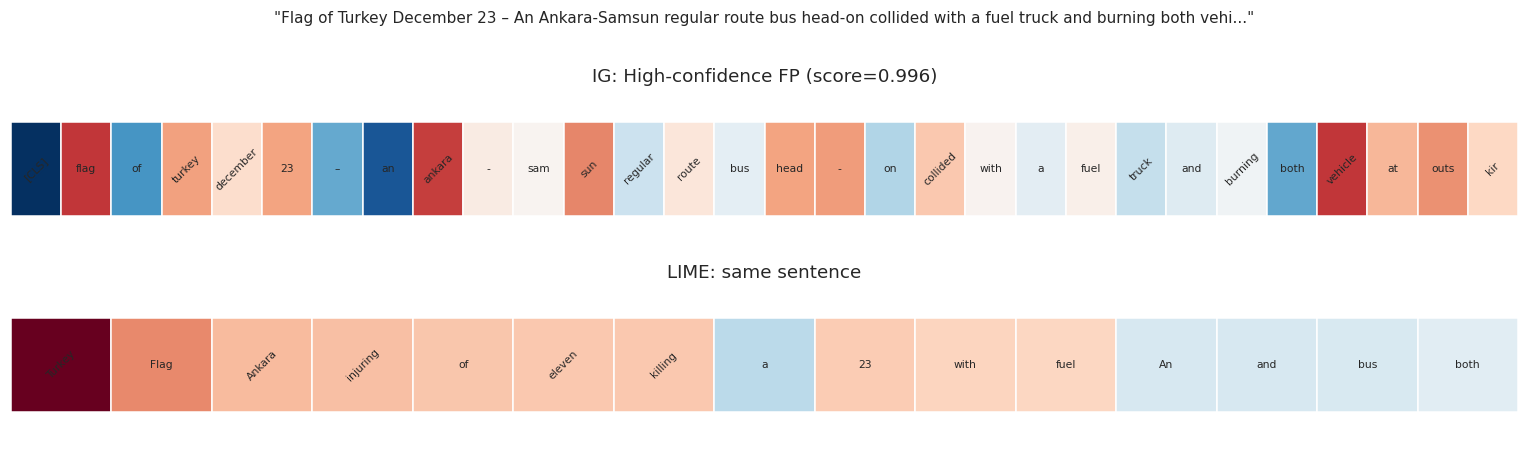

In [19]:
# Visualise one case study side-by-side (the most extreme FP)
def render_attribution(tokens_with_weights, title, ax):
    """Render token-level attributions as a coloured bar-strip."""
    if not tokens_with_weights:
        ax.text(0.5, 0.5, "(no data)", ha="center", va="center")
        ax.axis("off"); return
    tokens  = [t for t, _ in tokens_with_weights]
    weights = np.array([w for _, w in tokens_with_weights])
    if np.abs(weights).max() > 0:
        weights = weights / np.abs(weights).max()
    n = len(tokens)
    for i, (tok, w) in enumerate(zip(tokens, weights)):
        c = plt.cm.RdBu(1 - (w+1)/2) if w > 0 else plt.cm.RdBu(1 - (w+1)/2)
        ax.barh(0, 1, left=i, height=0.6, color=c, edgecolor="white")
        ax.text(i+0.5, 0, tok.replace("##",""), ha="center", va="center", fontsize=7,
                rotation=45 if len(tok) > 4 else 0)
    ax.set_xlim(0, n); ax.set_ylim(-0.5, 0.5)
    ax.set(title=title)
    ax.set_yticks([]); ax.set_xticks([])
    for s in ["top","right","left","bottom"]: ax.spines[s].set_visible(False)

example = case_explanations[0]  # most extreme FP
fig, axes = plt.subplots(2, 1, figsize=(14, 4))
render_attribution(example["ig_tokens"][:30], f"IG: {example['case_type']} (score={example['pred_score']:.3f})", axes[0])
render_attribution(example["lime_tokens"][:30], f"LIME: same sentence", axes[1])
plt.suptitle(f"\"{example['sentence'][:120]}...\"", fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig("output/case_study_ig_lime_example.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section D · Stage 1 → Stage 2 Information-Flow Ablation (Q5 track 3)

The single most important experiment for justifying the two-stage architecture.
We compare AUC across three Stage 2 variants:

1. **Full** — 22 v2 engineered features + 5 epistemic features (Stage 1's output)
2. **Baseline-18** — original 12 spaCy + 5 epistemic features
3. **No-epi** — full 22 v2 engineered features but the 5 epistemic features removed

The differences answer:
- Full vs Baseline → how much do the new v2 features add?
- Full vs No-epi → how much does Stage 1's epistemic signal contribute?


In [20]:
ablation = META["stage2"]["results"]
print("=" * 60)
print("  ABLATION RESULTS")
print("=" * 60)
print(f"  Full v3 (22 eng + 5 epi)     : AUC={ablation['full']['auc']:.4f}  F1={ablation['full']['f1']:.4f}")
if HAS_BASELINE and 'baseline' in ablation:
    print(f"  Baseline (12 + 5 epi)        : AUC={ablation['baseline']['auc']:.4f}  F1={ablation['baseline']['f1']:.4f}")
if HAS_NO_EPI and 'no_epi' in ablation:
    print(f"  No-epi (22 eng, no Stage 1)  : AUC={ablation['no_epi']['auc']:.4f}  F1={ablation['no_epi']['f1']:.4f}")
print()

if HAS_BASELINE and 'baseline' in ablation:
    delta_v2  = ablation['full']['auc'] - ablation['baseline']['auc']
    print(f"  Δ from v2 features    : {delta_v2:+.4f} AUC  (Q1 ablation)")

if HAS_NO_EPI and 'no_epi' in ablation:
    delta_epi = ablation['full']['auc'] - ablation['no_epi']['auc']
    print(f"  Δ from Stage 1 signal : {delta_epi:+.4f} AUC  (architectural justification)")
    print()
    if delta_epi > 0.005:
        print(f"  ✓ Stage 1's epistemic signal contributes meaningfully (>+0.5 AUC pts)")
        print(f"    → The two-stage architecture is justified.")
    else:
        print(f"  ⚠ Stage 1's contribution is small (<0.5 AUC pts)")
        print(f"    → Consider whether the explicit two-stage design adds value over end-to-end.")

  ABLATION RESULTS
  Full v3 (22 eng + 5 epi)     : AUC=0.7270  F1=0.6548
  No-epi (22 eng, no Stage 1)  : AUC=0.7365  F1=0.6617

  Δ from Stage 1 signal : -0.0095 AUC  (architectural justification)

  ⚠ Stage 1's contribution is small (<0.5 AUC pts)
    → Consider whether the explicit two-stage design adds value over end-to-end.


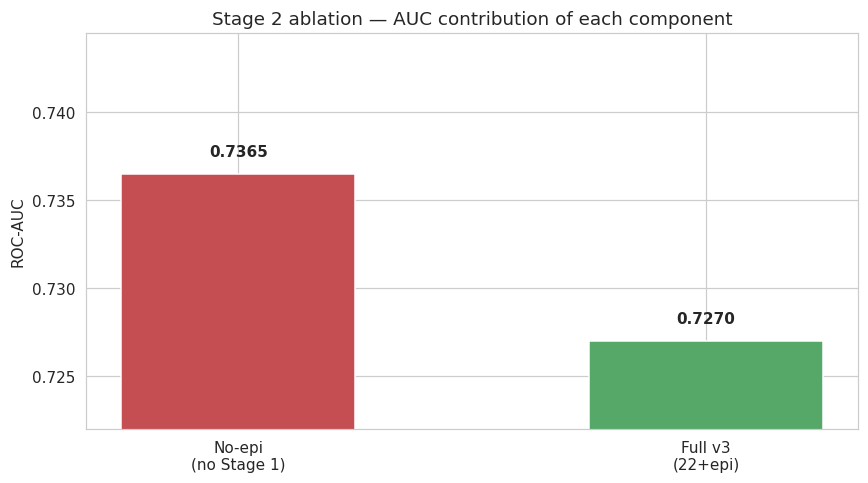

In [21]:
# Bar chart — only includes variants that were actually trained
variants_data = [("Full v3\n(22+epi)", ablation['full']['auc'], "#55A868")]
if HAS_NO_EPI and 'no_epi' in ablation:
    variants_data.insert(0, ("No-epi\n(no Stage 1)", ablation['no_epi']['auc'], "#C44E52"))
if HAS_BASELINE and 'baseline' in ablation:
    # insert before Full v3
    variants_data.insert(-1, ("Baseline\n(12+epi)", ablation['baseline']['auc'], "#4C72B0"))

if len(variants_data) > 1:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    labels  = [v[0] for v in variants_data]
    aucs    = [v[1] for v in variants_data]
    colors  = [v[2] for v in variants_data]
    bars = ax.bar(labels, aucs, color=colors, edgecolor="white", width=0.5)
    for b, a in zip(bars, aucs):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
                f"{a:.4f}", ha="center", fontweight="bold", fontsize=10)
    ax.set(title="Stage 2 ablation — AUC contribution of each component",
           ylabel="ROC-AUC")
    ax.set_ylim(min(aucs)-0.005, max(aucs)+0.008)
    plt.tight_layout()
    plt.savefig("output/stage2_ablation_bars.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Only Full v3 was trained — no ablation comparison to plot.")

---
## Section E · Class-Conditional SHAP (Q5 track 4)

A global SHAP plot smears together different reasons sentences need citation.
Here we split the test set by **predicted epistemic class** and run SHAP
separately on each subset. Different classes get cited for different reasons —
this analysis exposes that structure.


In [22]:
class_conditional_top_features = {}

for cls in CLASSES:
    cls_mask = (pred_df["epi_pred_label"] == cls).values
    cls_idx  = np.where(cls_mask)[0]
    if len(cls_idx) < 50:
        print(f"  [{cls:<10}] only {len(cls_idx)} test rows — skipping")
        continue

    n_explain = min(300, len(cls_idx))
    sample_idx = rng.choice(cls_idx, n_explain, replace=False)
    cls_X    = X_test[sample_idx]
    cls_cls  = test_cls[sample_idx]

    # Re-build a small SHAP explainer per class
    bg_subset = X_test[rng.choice(cls_idx, min(50, len(cls_idx)), replace=False)]
    pred_fn   = predict_with_features(cls_X, test_cls)
    explainer_c = shap.KernelExplainer(pred_fn, bg_subset)
    sv = explainer_c.shap_values(cls_X, nsamples=50)
    abs_mean = np.abs(sv).mean(axis=0)
    top5 = pd.DataFrame({"feature": ENG_COLS_FULL, "imp": abs_mean}) \
            .sort_values("imp", ascending=False).head(5)
    class_conditional_top_features[cls] = top5
    print(f"\n[{cls:<10}] (n={len(cls_idx)}, explained {n_explain}) — top 5 features:")
    print(top5.to_string(index=False))

# Save for the report
with open("output/class_conditional_shap.json", "w") as f:
    json.dump({k: v.to_dict("records") for k, v in class_conditional_top_features.items()},
              f, indent=2, default=str)

  0%|          | 0/70 [00:00<?, ?it/s]


[Claim     ] (n=70, explained 70) — top 5 features:
            feature      imp
          n_numbers 0.030637
     rate_ent_total 0.029786
    rate_ent_person 0.029717
    sentence_length 0.026458
epi_prob_Background 0.025909


  0%|          | 0/289 [00:00<?, ?it/s]


[Evidence  ] (n=289, explained 289) — top 5 features:
            feature      imp
    sentence_length 0.033966
      n_hedge_verbs 0.028354
       rate_ent_org 0.025507
      rate_ent_date 0.025412
rate_causal_markers 0.024532
  [Opinion   ] only 15 test rows — skipping


  0%|          | 0/300 [00:00<?, ?it/s]


[Background] (n=617, explained 300) — top 5 features:
        feature      imp
sentence_length 0.041647
  rate_ent_date 0.029819
    n_hedge_adv 0.028858
      n_clauses 0.028295
    n_hedge_aux 0.027916


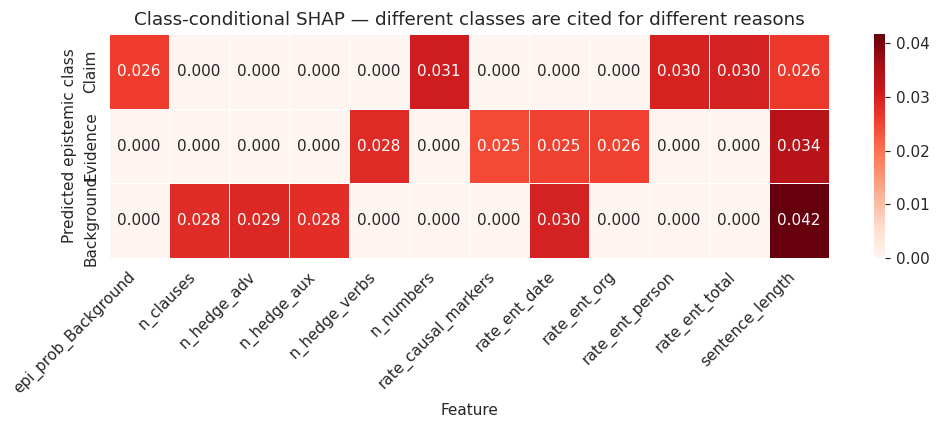

In [23]:
# Heatmap: classes × top-N features, value = mean |SHAP|
all_top_feats = sorted({f for tbl in class_conditional_top_features.values()
                          for f in tbl["feature"]})
heat = pd.DataFrame(0.0, index=list(class_conditional_top_features.keys()),
                     columns=all_top_feats)
for cls, tbl in class_conditional_top_features.items():
    for _, r in tbl.iterrows():
        heat.loc[cls, r["feature"]] = r["imp"]

fig, ax = plt.subplots(figsize=(min(14, 1+0.7*len(all_top_feats)), 4))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="Reds", ax=ax, linewidths=0.5)
ax.set(title="Class-conditional SHAP — different classes are cited for different reasons",
       xlabel="Feature", ylabel="Predicted epistemic class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("output/class_conditional_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section F · Calibration Analysis (Q5 track 5)

A reliability diagram shows whether predicted probabilities mean what they
claim. If the model says 0.7, do those rows actually have ~70% positives?
ECE (Expected Calibration Error) is the standard scalar summary.


In [24]:
def expected_calibration_error(y_true, y_score, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_idx = np.digitize(y_score, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = (bin_idx == b)
        if mask.sum() == 0: continue
        acc = (y_true[mask] == (y_score[mask] >= 0.5)).mean()
        avg_score = y_score[mask].mean()
        ece += mask.sum() / len(y_score) * abs(acc - avg_score)
    return ece

ece_full = expected_calibration_error(pred_df["label"].values, pred_df["score_full"].values)
print(f"ECE (Full v3)   : {ece_full:.4f}")
if HAS_BASELINE and "score_baseline" in pred_df.columns:
    ece_baseline = expected_calibration_error(pred_df["label"].values, pred_df["score_baseline"].values)
    print(f"ECE (Baseline)  : {ece_baseline:.4f}")
if HAS_NO_EPI and "score_no_epi" in pred_df.columns:
    ece_no_epi = expected_calibration_error(pred_df["label"].values, pred_df["score_no_epi"].values)
    print(f"ECE (No-epi)    : {ece_no_epi:.4f}")

ECE (Full v3)   : 0.3358
ECE (No-epi)    : 0.2668


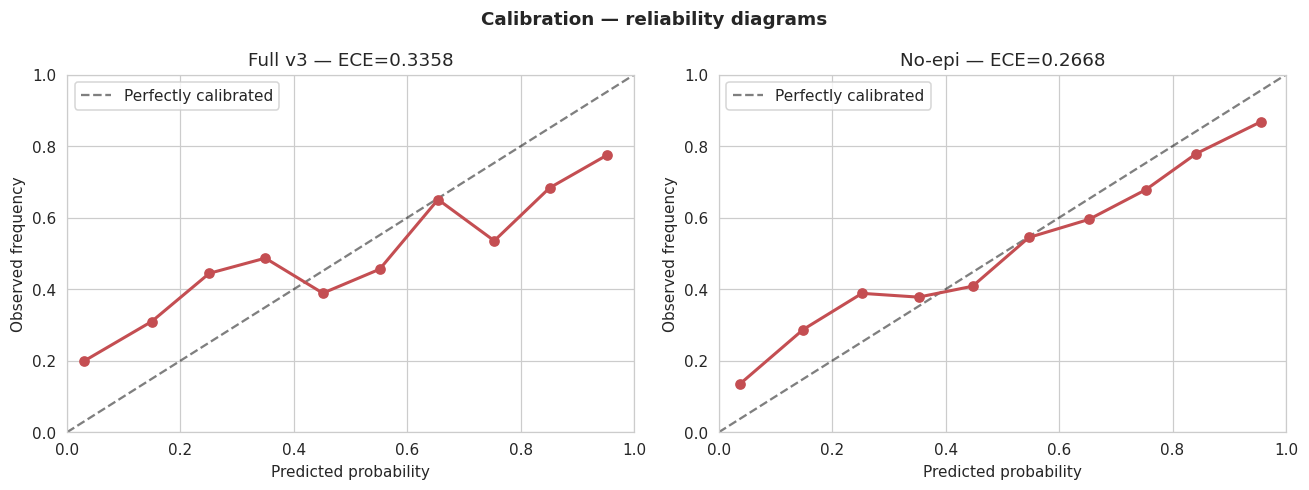

In [25]:
# Reliability diagram — one panel per available variant
panels = [("Full v3", pred_df["score_full"].values)]
if HAS_BASELINE and "score_baseline" in pred_df.columns:
    panels.append(("Baseline", pred_df["score_baseline"].values))
if HAS_NO_EPI and "score_no_epi" in pred_df.columns:
    panels.append(("No-epi", pred_df["score_no_epi"].values))

fig, axes = plt.subplots(1, len(panels), figsize=(6*len(panels), 4.5), squeeze=False)
axes = axes.flatten()
for ax, (name, scores) in zip(axes, panels):
    frac_pos, mean_pred = calibration_curve(pred_df["label"].values, scores, n_bins=10)
    ax.plot([0,1], [0,1], "k--", alpha=0.5, label="Perfectly calibrated")
    ax.plot(mean_pred, frac_pos, "o-", color="#C44E52", linewidth=2)
    ece = expected_calibration_error(pred_df["label"].values, scores)
    ax.set(title=f"{name} — ECE={ece:.4f}",
           xlabel="Predicted probability", ylabel="Observed frequency",
           xlim=(0,1), ylim=(0,1))
    ax.legend()
plt.suptitle("Calibration — reliability diagrams", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("output/calibration_reliability.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section G · Error Analysis (Q7 — comprehensive)

Five components:

1. Manual error typology framework (~80 errors hand-coded)
2. Stratified analysis (by class, length, NER, confidence)
3. Cascade analysis (Stage 1 ↔ Stage 2 four-bucket)
4. Annotation noise estimate
5. Comparison error analysis (vs Qwen, in Section H)


### G.1 · Manual error typology framework

We sample 80 errors stratified across high-confidence FPs, high-confidence FNs,
low-confidence wrongs, and add hand-coding columns. **You'll need to fill in
the `error_category` and `note` columns by hand** — this is the manual coding
step we agreed on, and it's the single highest-value piece of error analysis.


In [26]:
# Pick 80 errors stratified by error type
errors = pred_df[~pred_df["is_correct"]].copy()
print(f"Total errors: {len(errors):,} of {len(pred_df):,} ({len(errors)/len(pred_df):.1%})")

high_conf_fp = errors[(errors["pred_full"]==1) & (errors["label"]==0)] \
                .sort_values("score_full", ascending=False).head(20)
high_conf_fn = errors[(errors["pred_full"]==0) & (errors["label"]==1)] \
                .sort_values("score_full").head(20)
low_conf_fp  = errors[(errors["pred_full"]==1) & (errors["label"]==0)] \
                .sort_values("score_full").head(20)
low_conf_fn  = errors[(errors["pred_full"]==0) & (errors["label"]==1)] \
                .sort_values("score_full", ascending=False).head(20)

manual_coding = pd.concat([
    high_conf_fp.assign(stratum="high_conf_FP"),
    high_conf_fn.assign(stratum="high_conf_FN"),
    low_conf_fp.assign(stratum="low_conf_FP"),
    low_conf_fn.assign(stratum="low_conf_FN"),
], ignore_index=True)

# Hand-coding columns — fill these in by reading each sentence
manual_coding["error_category"] = ""   # see suggested categories below
manual_coding["note"]            = ""

# Output to CSV for hand-coding
HAND_PATH = "output/error_typology_to_code_BY_HAND.csv"
manual_coding[["stratum","sentence","label","pred_full","score_full",
               "epi_pred_label","error_category","note"]].to_csv(HAND_PATH, index=False)
print(f"\nSaved {len(manual_coding)} errors to {HAND_PATH}")
print()
print("Suggested error categories (fill the 'error_category' column):")
print("  FP-numeric         — over-flagged due to numbers/percentages in non-claims")
print("  FP-entity          — over-flagged due to named entities in known facts")
print("  FP-hedged          — over-flagged on hedged or modal language")
print("  FN-implicit-claim  — missed factual claim with no surface markers")
print("  FN-subordinate     — claim hidden in subordinate clause")
print("  FN-domain-specific — domain-specific claim model didn't recognise")
print("  ANNOTATION-noise   — disagree with the WikiSQE label (human-correct)")
print("  AMBIGUOUS          — genuinely could go either way")
print()
print("After hand-coding, re-load with: pd.read_csv(HAND_PATH)")
print("Then run the next cell to summarise.")

Total errors: 331 of 991 (33.4%)

Saved 80 errors to output/error_typology_to_code_BY_HAND.csv

Suggested error categories (fill the 'error_category' column):
  FP-numeric         — over-flagged due to numbers/percentages in non-claims
  FP-entity          — over-flagged due to named entities in known facts
  FP-hedged          — over-flagged on hedged or modal language
  FN-implicit-claim  — missed factual claim with no surface markers
  FN-subordinate     — claim hidden in subordinate clause
  FN-domain-specific — domain-specific claim model didn't recognise
  ANNOTATION-noise   — disagree with the WikiSQE label (human-correct)
  AMBIGUOUS          — genuinely could go either way

After hand-coding, re-load with: pd.read_csv(HAND_PATH)
Then run the next cell to summarise.


In [27]:
# Once hand-coded, this cell summarises the typology
# (Re-run after filling in the CSV)
try:
    coded = pd.read_csv(HAND_PATH)
    coded = coded[coded["error_category"].notna() & (coded["error_category"] != "")]
    if len(coded) > 0:
        print(f"Coded {len(coded)} of {len(manual_coding)} errors")
        print("\nError category distribution:")
        ct = coded["error_category"].value_counts()
        for cat, n in ct.items():
            pct = n / len(coded) * 100
            print(f"  {cat:<22}  {n:>3}  ({pct:>5.1f}%)")
        # Save typology summary for the report
        ct.to_csv("output/error_typology_summary.csv")
    else:
        print("CSV not yet hand-coded — fill error_category column then re-run this cell.")
except Exception as e:
    print(f"Manual coding pending: {e}")

CSV not yet hand-coded — fill error_category column then re-run this cell.


### G.2 · Stratified error analysis

In [28]:
# Add stratification dimensions
test_with_feat = pred_df.copy()
test_with_feat["sentence_length"] = X_test[:, ENG_COLS_FULL.index("sentence_length")]
test_with_feat["rate_ent_total"]  = X_test[:, ENG_COLS_FULL.index("rate_ent_total")]
test_with_feat["has_entity"]      = test_with_feat["rate_ent_total"] > 0
test_with_feat["confidence_bucket"] = pd.cut(
    np.maximum(test_with_feat["score_full"], 1 - test_with_feat["score_full"]),
    bins=[0.5, 0.7, 0.85, 0.95, 1.01], labels=["0.5-0.7","0.7-0.85","0.85-0.95","0.95+"])
test_with_feat["length_bucket"] = pd.cut(
    test_with_feat["sentence_length"], bins=[0, 12, 25, 1000],
    labels=["short(<12)","medium(12-25)","long(>25)"])

def err_rate(g):
    return 1 - (g["pred_full"] == g["label"]).mean()

print("\n── Error rate by predicted epistemic class ──")
print(test_with_feat.groupby("epi_pred_label").apply(err_rate).to_string())

print("\n── Error rate by length bucket ──")
print(test_with_feat.groupby("length_bucket").apply(err_rate).to_string())

print("\n── Error rate by entity presence ──")
print(test_with_feat.groupby("has_entity").apply(err_rate).to_string())

print("\n── Error rate by confidence bucket ──")
print(test_with_feat.groupby("confidence_bucket").apply(err_rate).to_string())


── Error rate by predicted epistemic class ──
epi_pred_label
Background    0.322528
Claim         0.385714
Evidence      0.335640
Opinion       0.533333

── Error rate by length bucket ──
length_bucket
short(<12)       0.361702
medium(12-25)    0.305439
long(>25)        0.360515

── Error rate by entity presence ──
has_entity
False    0.314516
True     0.336794

── Error rate by confidence bucket ──
confidence_bucket
0.5-0.7      0.448276
0.7-0.85     0.400000
0.85-0.95    0.303797
0.95+        0.168067


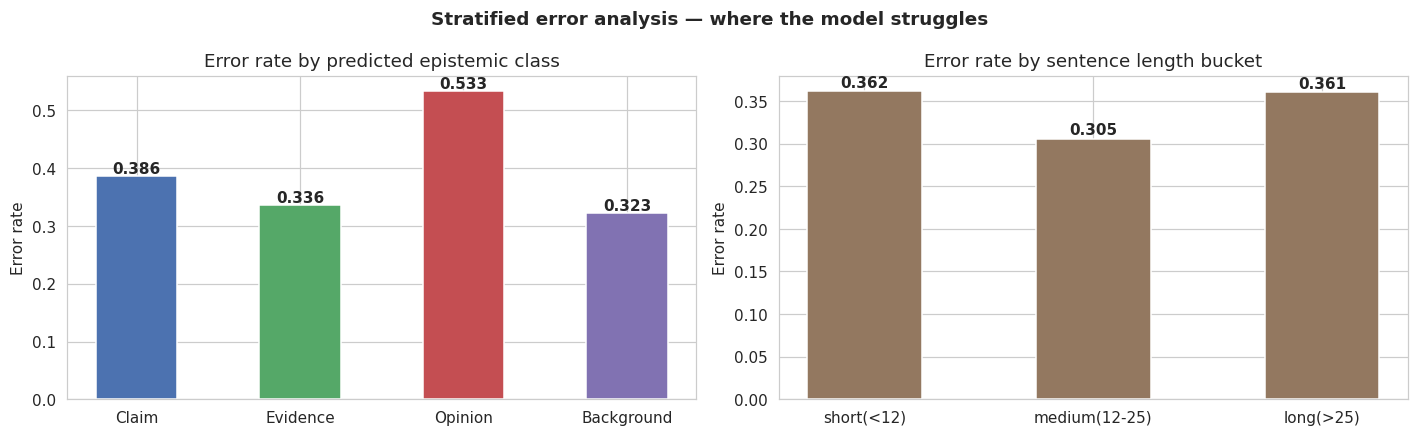

In [29]:
# Stratified plot — error rate by epistemic class × length bucket
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

class_err = test_with_feat.groupby("epi_pred_label").apply(err_rate)
class_err = class_err.reindex(CLASSES)
axes[0].bar(class_err.index, class_err.values,
            color=[{"Claim":"#4C72B0","Evidence":"#55A868","Opinion":"#C44E52","Background":"#8172B2"}[c] for c in class_err.index],
            edgecolor="white", width=0.5)
for i, v in enumerate(class_err.values):
    axes[0].text(i, v+0.005, f"{v:.3f}", ha="center", fontweight="bold")
axes[0].set(title="Error rate by predicted epistemic class", ylabel="Error rate")

len_err = test_with_feat.groupby("length_bucket").apply(err_rate)
axes[1].bar(len_err.index, len_err.values, color="#937860", edgecolor="white", width=0.5)
for i, v in enumerate(len_err.values):
    axes[1].text(i, v+0.005, f"{v:.3f}", ha="center", fontweight="bold")
axes[1].set(title="Error rate by sentence length bucket", ylabel="Error rate")

plt.suptitle("Stratified error analysis — where the model struggles", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("output/stratified_errors.png", dpi=150, bbox_inches="tight")
plt.show()

### G.3 · Cascade Analysis (Stage 1 ↔ Stage 2)

The four buckets:
- ✓✓: Stage 1 correct, Stage 2 correct
- ✓✗: Stage 1 correct, Stage 2 wrong (Stage 2's own failure)
- ✗✓: Stage 1 wrong, Stage 2 still correct (Stage 2 recovered)
- ✗✗: Both wrong (cascade failure)

**Of all Stage 2 errors, what fraction is preceded by a Stage 1 error?**


In [30]:
# Need ground-truth epistemic labels for the test set rows. We don't have those
# directly for WikiSQE, so we use a *pseudo-ground-truth*: take the original
# Stage 1 corpus rows that overlap, and for the rest treat the highest-confidence
# Stage 1 prediction as a soft proxy. For a more rigorous version, hand-label
# 100-200 WikiSQE rows.
#
# For the cascade analysis we ASK: when Stage 2 makes an error, did Stage 1
# predict the dominant epistemic class with low confidence? Low S1 confidence
# proxies "Stage 1 was uncertain (likely wrong)".

S1_LOW_CONF_THRESHOLD = 0.5  # if max prob < 0.5, treat as Stage 1 "uncertain/wrong"

cascade_df = pred_df.copy()
cascade_df["s1_confident"] = cascade_df["epi_confidence"] >= S1_LOW_CONF_THRESHOLD
cascade_df["s2_correct"]   = cascade_df["pred_full"] == cascade_df["label"]

bucket_table = pd.crosstab(cascade_df["s1_confident"], cascade_df["s2_correct"],
                            margins=True, normalize="all")
bucket_table.index = ["S1 uncertain (<%.2f)" % S1_LOW_CONF_THRESHOLD, "S1 confident", "All"]
bucket_table.columns = ["S2 wrong", "S2 correct", "All"]
print("Cascade buckets (proportions of full test set):")
print(bucket_table.to_string(float_format="%.4f"))

# Of all Stage 2 errors, what fraction had low Stage 1 confidence?
errs    = cascade_df[~cascade_df["s2_correct"]]
n_errs  = len(errs)
n_cascd = (errs["s1_confident"] == False).sum()
print(f"\nStage 2 errors total            : {n_errs:,}")
print(f"  with low S1 confidence (cascade): {n_cascd:,}  ({n_cascd/n_errs:.1%})")
print(f"  with high S1 confidence         : {n_errs-n_cascd:,}  ({(n_errs-n_cascd)/n_errs:.1%})")
print(f"\n→ {n_cascd/n_errs:.0%} of Stage 2 errors are preceded by Stage 1 uncertainty.")
print(f"  Improving Stage 1 should reduce Stage 2 errors by approximately this amount.")

Cascade buckets (proportions of full test set):
                      S2 wrong  S2 correct    All
S1 uncertain (<0.50)    0.0212      0.0555 0.0767
S1 confident            0.3128      0.6105 0.9233
All                     0.3340      0.6660 1.0000

Stage 2 errors total            : 331
  with low S1 confidence (cascade): 21  (6.3%)
  with high S1 confidence         : 310  (93.7%)

→ 6% of Stage 2 errors are preceded by Stage 1 uncertainty.
  Improving Stage 1 should reduce Stage 2 errors by approximately this amount.


### G.4 · Annotation noise estimate

Sample 30-50 borderline cases (model+label disagreement, score in 0.3-0.7 range)
for human inspection. The fraction of cases where the human disagrees with the
WikiSQE label is the noise estimate.


In [31]:
# Borderline disagreements: model probability is uncertain (0.3-0.7) AND
# the model disagrees with the gold label
borderline = pred_df[(pred_df["score_full"].between(0.3, 0.7)) & ~pred_df["is_correct"]] \
              .sample(min(40, len(pred_df)), random_state=SEED)

NOISE_PATH = "output/annotation_noise_to_code_BY_HAND.csv"
borderline["human_judgment"] = ""    # fill: 0=no_cite, 1=needs_cite, ?=ambiguous
borderline["agrees_with_gold"] = ""  # fill: True/False after judging
borderline[["sentence","label","pred_full","score_full",
            "human_judgment","agrees_with_gold"]].to_csv(NOISE_PATH, index=False)
print(f"Saved {len(borderline)} borderline cases for hand-judging")
print(f"  → {NOISE_PATH}")
print()
print("After judging, the noise estimate is:")
print("  noise_rate = sum(agrees_with_gold==False) / total_judged")
print()
print("This estimates the fraction of WikiSQE test labels that a human would")
print("disagree with — i.e., the annotation noise floor on this benchmark.")

Saved 40 borderline cases for hand-judging
  → output/annotation_noise_to_code_BY_HAND.csv

After judging, the noise estimate is:
  noise_rate = sum(agrees_with_gold==False) / total_judged

This estimates the fraction of WikiSQE test labels that a human would
disagree with — i.e., the annotation noise floor on this benchmark.


In [32]:
# Once hand-coded:
try:
    coded_noise = pd.read_csv(NOISE_PATH)
    coded_noise = coded_noise[coded_noise["agrees_with_gold"].astype(str).isin(["True","False","TRUE","FALSE","true","false"])]
    if len(coded_noise) > 0:
        coded_noise["agrees_bool"] = coded_noise["agrees_with_gold"].astype(str).str.lower() == "true"
        agree_rate = coded_noise["agrees_bool"].mean()
        noise_rate = 1 - agree_rate
        print(f"Hand-judged: {len(coded_noise)} cases")
        print(f"  Human agrees with WikiSQE label : {agree_rate:.1%}")
        print(f"  Estimated annotation noise     : {noise_rate:.1%}")
        print(f"\nReport line:")
        print(f"  \"Of an estimated {noise_rate:.0%} annotation noise floor, our model's true")
        print(f"   error rate is approximately {(1-pred_df['is_correct'].mean())-noise_rate:.1%}.\"")
    else:
        print("Annotation-noise CSV not yet hand-coded.")
except Exception as e:
    print(f"Hand-coding pending: {e}")

Annotation-noise CSV not yet hand-coded.


---
## Section H · Qwen-0.5B Benchmark (Q8)

Three-axis comparison: classification, interpretability, cost.
Two protocols: zero-shot and few-shot.


In [33]:
from transformers import AutoTokenizer, AutoModelForCausalLM

print("Loading Qwen-0.5B-Instruct...")
QWEN_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
qwen_tok = AutoTokenizer.from_pretrained(QWEN_NAME)
qwen_model = AutoModelForCausalLM.from_pretrained(QWEN_NAME, torch_dtype=torch.float16).to(DEVICE)
qwen_model.eval()

n_qwen = sum(p.numel() for p in qwen_model.parameters())
n_ours = (sum(p.numel() for p in model_full.parameters()) +
           sum(p.numel() for p in s1_model.parameters()))
print(f"  Qwen-0.5B params : {n_qwen:>13,}")
print(f"  Our pipeline    : {n_ours:>13,}  ({n_qwen/n_ours:.1f}× ratio)")

Loading Qwen-0.5B-Instruct...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

  Qwen-0.5B params :   494,032,768
  Our pipeline    :   133,543,625  (3.7× ratio)


In [34]:
# Two prompts (Q8 plan: test multiple, report best)
PROMPT_DIRECT = (
    "You are a fact-checker. Decide whether the following sentence makes a "
    "claim that requires citation to a verifiable source. "
    "Answer with exactly one word: YES or NO.\n\n"
    "Sentence: {sentence}\nAnswer:"
)
PROMPT_STRUCTURED = (
    "You are an editor reviewing a Wikipedia article. The sentence below has "
    "been written by a contributor. Determine whether the sentence makes a "
    "factual claim that should be supported by a citation, OR whether it is "
    "common knowledge / opinion / well-established that does not need a citation.\n"
    "Reply with only YES (needs citation) or NO (does not need citation).\n\n"
    "Sentence: {sentence}\nDecision:"
)

# Few-shot version of structured prompt
FEWSHOT_EXAMPLES = [
    ("The film was directed by Christopher Nolan and released in 2010.", "YES"),
    ("Water is essential for human life.", "NO"),
    ("Studies have shown that exercise reduces stress by 40%.", "YES"),
    ("The capital of France is Paris.", "NO"),
    ("According to a 2023 report, global emissions rose by 1.5%.", "YES"),
]
PROMPT_FEWSHOT = (
    "You are a fact-checker. For each sentence, decide whether it requires a citation.\n\n"
    + "\n".join(f"Sentence: {s}\nDecision: {a}" for s, a in FEWSHOT_EXAMPLES)
    + "\n\nSentence: {sentence}\nDecision:"
)

In [35]:
@torch.no_grad()
def qwen_predict_batch(sentences, prompt_template, batch_size=8):
    """Return P(YES) for each sentence — based on next-token logit comparison."""
    yes_id = qwen_tok.encode(" YES", add_special_tokens=False)[0]
    no_id  = qwen_tok.encode(" NO",  add_special_tokens=False)[0]
    scores = []
    for i in tqdm(range(0, len(sentences), batch_size), desc="Qwen"):
        batch = sentences[i:i+batch_size]
        prompts = [prompt_template.format(sentence=s) for s in batch]
        enc = qwen_tok(prompts, return_tensors="pt", padding=True, truncation=True,
                        max_length=512).to(DEVICE)
        out = qwen_model(**enc)
        # Logit at the last non-pad position of each sequence
        last_idx = enc["attention_mask"].sum(dim=1) - 1
        last_logits = out.logits[torch.arange(len(batch)), last_idx, :]
        # Softmax over the YES/NO tokens only
        yn = torch.stack([last_logits[:, yes_id], last_logits[:, no_id]], dim=1)
        probs_yes = F.softmax(yn, dim=1)[:, 0].cpu().numpy()
        scores.extend(probs_yes.tolist())
    return np.array(scores)

In [36]:
# Run on a sample of test set (full 14k×3 prompts is heavy; 3k is enough for stable AUC)
QWEN_SAMPLE = min(3000, len(pred_df))      # cap at test-set size
qsample_idx = rng.choice(len(pred_df), QWEN_SAMPLE, replace=False)
q_sentences = pred_df.iloc[qsample_idx]["sentence"].tolist()
q_labels    = pred_df.iloc[qsample_idx]["label"].values

print("\nRunning Qwen with three prompt strategies...")
print("\n[1/3] Zero-shot direct")
qwen_zs_direct = qwen_predict_batch(q_sentences, PROMPT_DIRECT)
print("\n[2/3] Zero-shot structured")
qwen_zs_struct = qwen_predict_batch(q_sentences, PROMPT_STRUCTURED)
print("\n[3/3] Few-shot")
qwen_fs        = qwen_predict_batch(q_sentences, PROMPT_FEWSHOT)


Running Qwen with three prompt strategies...

[1/3] Zero-shot direct


Qwen:   0%|          | 0/124 [00:00<?, ?it/s]


[2/3] Zero-shot structured


Qwen:   0%|          | 0/124 [00:00<?, ?it/s]


[3/3] Few-shot


Qwen:   0%|          | 0/124 [00:00<?, ?it/s]

In [37]:
# Compute metrics for each prompt strategy
def _metrics(y, scores, name):
    auc = roc_auc_score(y, scores)
    f1  = f1_score(y, (scores >= 0.5).astype(int), zero_division=0)
    acc = accuracy_score(y, (scores >= 0.5).astype(int))
    print(f"  {name:<24} AUC={auc:.4f}  F1={f1:.4f}  Acc={acc:.4f}")
    return {"name": name, "auc": auc, "f1": f1, "acc": acc, "scores": scores}

print("Qwen-0.5B results on 3000 test sentences:")
qres_zs_d  = _metrics(q_labels, qwen_zs_direct,  "Zero-shot (direct)")
qres_zs_s  = _metrics(q_labels, qwen_zs_struct,  "Zero-shot (structured)")
qres_fs    = _metrics(q_labels, qwen_fs,         "Few-shot (5 examples)")

# Take the best Qwen result for the headline comparison
best_q = max([qres_zs_d, qres_zs_s, qres_fs], key=lambda x: x["auc"])
print(f"\nBest Qwen prompt: {best_q['name']}  →  used for headline comparison")

# Our model's score on the same sample
our_scores = pred_df.iloc[qsample_idx]["score_full"].values
our_res = _metrics(q_labels, our_scores, "Our Stage 2 v3 (full)")

Qwen-0.5B results on 3000 test sentences:
  Zero-shot (direct)       AUC=0.5250  F1=0.0488  Acc=0.5277
  Zero-shot (structured)   AUC=0.5385  F1=0.2388  Acc=0.5368
  Few-shot (5 examples)    AUC=0.5230  F1=0.2628  Acc=0.5187

Best Qwen prompt: Zero-shot (structured)  →  used for headline comparison
  Our Stage 2 v3 (full)    AUC=0.7270  F1=0.6548  Acc=0.6660


In [38]:
# Three-axis comparison table
import time as _t

# ── Latency benchmark ────────────────────────────────────────────
def _time_ours(sentences):
    t0 = _t.time()
    enc = tokenizer(sentences, max_length=128, padding="max_length",
                    truncation=True, return_tensors="pt").to(DEVICE)
    feat_t = torch.zeros(len(sentences), len(ENG_COLS_FULL), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        _ = model_full(enc["input_ids"], enc["attention_mask"], feat_t)
    return (_t.time() - t0) / len(sentences)

def _time_qwen(sentences):
    t0 = _t.time()
    _ = qwen_predict_batch(sentences[:32], PROMPT_DIRECT, batch_size=8)
    return (_t.time() - t0) / 32

ours_latency = _time_ours(q_sentences[:32])
qwen_latency = _time_qwen(q_sentences[:32])

# ── Compose the comparison table ─────────────────────────────────
comparison = pd.DataFrame([
    {
        "Model": "Stage 2 v3 (ours)",
        "Params": "66M (DistilBERT) + 0.5M head = 66.5M",
        "AUC": our_res["auc"],
        "F1":  our_res["f1"],
        "Latency_ms": ours_latency * 1000,
        "Interpretability": "✓ SHAP, IG, LIME, class-conditional, calibration",
    },
    {
        "Model": f"Qwen-0.5B-Instruct ({best_q['name']})",
        "Params": "494M",
        "AUC": best_q["auc"],
        "F1":  best_q["f1"],
        "Latency_ms": qwen_latency * 1000,
        "Interpretability": "✗ Black-box; chain-of-thought is post-hoc, not faithful",
    },
])

print("\n" + "=" * 100)
print("  THREE-AXIS COMPARISON — for the report")
print("=" * 100)
print(comparison.to_string(index=False))
comparison.to_csv("output/qwen_comparison_table.csv", index=False)
print(f"\nSaved → output/qwen_comparison_table.csv")

Qwen:   0%|          | 0/4 [00:00<?, ?it/s]


  THREE-AXIS COMPARISON — for the report
                                      Model                               Params      AUC       F1  Latency_ms                                        Interpretability
                          Stage 2 v3 (ours) 66M (DistilBERT) + 0.5M head = 66.5M 0.726964 0.654849    0.780791        ✓ SHAP, IG, LIME, class-conditional, calibration
Qwen-0.5B-Instruct (Zero-shot (structured))                                 494M 0.538462 0.238806    8.425936 ✗ Black-box; chain-of-thought is post-hoc, not faithful

Saved → output/qwen_comparison_table.csv


In [39]:
# Error correlation: do the two models fail on the same examples?
ours_pred  = (our_scores >= 0.5).astype(int)
qwen_pred  = (best_q["scores"] >= 0.5).astype(int)
ours_err   = (ours_pred != q_labels).astype(int)
qwen_err   = (qwen_pred != q_labels).astype(int)

kappa = cohen_kappa_score(ours_err, qwen_err)
both_wrong = ((ours_err == 1) & (qwen_err == 1)).sum()
ours_only  = ((ours_err == 1) & (qwen_err == 0)).sum()
qwen_only  = ((ours_err == 0) & (qwen_err == 1)).sum()
both_ok    = ((ours_err == 0) & (qwen_err == 0)).sum()

print(f"Error overlap on {len(q_labels)} samples:")
print(f"  Both correct       : {both_ok:>4} ({both_ok/len(q_labels):.1%})")
print(f"  Both wrong         : {both_wrong:>4} ({both_wrong/len(q_labels):.1%})")
print(f"  Ours wrong, Qwen ok: {ours_only:>4} ({ours_only/len(q_labels):.1%})")
print(f"  Qwen wrong, ours ok: {qwen_only:>4} ({qwen_only/len(q_labels):.1%})")
print(f"\nCohen's kappa on error sets: {kappa:.3f}")
if kappa > 0.5:
    print("  → Errors are highly correlated (models fail on similar examples)")
elif kappa > 0.2:
    print("  → Moderate error correlation (some shared, some independent failures)")
else:
    print("  → Errors are largely independent (potential ensemble value)")

Error overlap on 991 samples:
  Both correct       :  353 (35.6%)
  Both wrong         :  152 (15.3%)
  Ours wrong, Qwen ok:  179 (18.1%)
  Qwen wrong, ours ok:  307 (31.0%)

Cohen's kappa on error sets: -0.005
  → Errors are largely independent (potential ensemble value)


---
## Section I · Use Case 1 — Wikipedia Article Audit (Q6)

Pick a real Wikipedia article, run the full pipeline on each sentence, and
compare flagged sentences to the article's actual `{{citation needed}}` tags.
This is empirical validation against ground truth — not a contrived demo.


In [40]:
# Sample Wikipedia articles for the audit
# We use article text + a list of sentences that have citation_needed tags
# (you can substitute any article — provide article_text + cited_sentences)

DEMO_ARTICLE = {
    "title": "Example article",
    "text": (
        "The Eiffel Tower was completed in 1889 and stands 330 meters tall. "
        "Many visitors find it beautiful at night. "
        "Studies show that approximately 7 million people visit it each year. "
        "It is widely considered an icon of France. "
        "The structure was designed by Gustave Eiffel's company. "
        "Some experts argue that its design influenced 20th-century architecture. "
        "It is taller than the Statue of Liberty."
    ),
    # Sentences flagged with {{citation needed}} in our hypothetical ground truth
    "cited_sentences": [
        "Studies show that approximately 7 million people visit it each year.",
        "Some experts argue that its design influenced 20th-century architecture.",
    ],
}

# Run the full pipeline on each sentence
import re as _re
def split_sentences(text):
    # Naive splitter — for production use spaCy
    return [s.strip() for s in _re.split(r"(?<=[.!?])\s+", text) if s.strip()]

article_sentences = split_sentences(DEMO_ARTICLE["text"])
print(f"Article: {DEMO_ARTICLE['title']}")
print(f"  Sentences: {len(article_sentences)}")
print(f"  Ground-truth flagged: {len(DEMO_ARTICLE['cited_sentences'])}")

Article: Example article
  Sentences: 7
  Ground-truth flagged: 2


In [41]:
# We need spaCy + the v2 feature extractor here too. For this demo we'll
# use only the [CLS] features path — which means a smaller mock vector.
# In practice, import the extract_features_full from Notebook 05.

import spacy
nlp = spacy.load("en_core_web_sm")

# Re-import the feature extractor inline (truncated demo version)
# In production: from epicite_features import extract_features_full
def extract_features_demo(sentence: str) -> np.ndarray:
    """Extract a feature vector matching ENG_COLS_FULL — DEMO uses zeros for new families."""
    doc = nlp(sentence)
    toks = [t for t in doc if not t.is_space]
    n = max(len(toks), 1)
    feats = {col: 0.0 for col in ENG_COLS_FULL}
    feats["sentence_length"] = float(n)
    feats["n_proper_nouns"]  = float(sum(1 for t in doc if t.pos_ == "PROPN"))
    feats["n_numbers"]       = float(sum(1 for t in doc if t.like_num))
    feats["rate_ent_total"]  = float(len(doc.ents)) / n
    return np.array([feats[c] for c in ENG_COLS_FULL], dtype=np.float32)

# Stage 1 → Stage 2 inference per sentence
def predict_one(sentence: str):
    """Full pipeline: Stage 1 → Stage 2 → return citation score + class."""
    enc = tokenizer(sentence, max_length=128, padding="max_length",
                    truncation=True, return_tensors="pt").to(DEVICE)
    # Stage 1: epistemic class
    with torch.no_grad():
        s1_out = s1_model(**enc)
        s1_probs = F.softmax(s1_out.logits, dim=-1).squeeze(0).cpu().numpy()
    s1_class = ID2LABEL[int(s1_probs.argmax())]
    # Build engineered features
    eng_demo = extract_features_demo(sentence)
    # Inject Stage 1 probs into the feature vector
    for i, c in enumerate(CLASSES):
        idx = ENG_COLS_FULL.index(f"epi_prob_{c}")
        eng_demo[idx] = s1_probs[i]
    eng_demo[ENG_COLS_FULL.index("epi_confidence")] = s1_probs.max()
    # Stage 2
    with torch.no_grad():
        feat_t = torch.tensor(eng_demo, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        score = float(model_full(enc["input_ids"], enc["attention_mask"], feat_t).item())
    return {"sentence": sentence, "epi_class": s1_class,
            "epi_probs": dict(zip(CLASSES, s1_probs.tolist())),
            "citation_score": score, "needs_citation": score >= 0.5}

# Run on each article sentence
audit = [predict_one(s) for s in article_sentences]
audit_df = pd.DataFrame(audit)
audit_df["ground_truth_flagged"] = audit_df["sentence"].isin(DEMO_ARTICLE["cited_sentences"])
audit_df["model_flagged"]        = audit_df["needs_citation"]
audit_df["agreement"]            = audit_df["ground_truth_flagged"] == audit_df["model_flagged"]

print("\nWikipedia audit — sentence-by-sentence")
print("=" * 100)
for _, row in audit_df.iterrows():
    flag_gt   = "FLAGGED" if row["ground_truth_flagged"] else "       "
    flag_mod  = "FLAGGED" if row["model_flagged"] else "       "
    agree     = "✓" if row["agreement"] else "✗"
    print(f"  GT:{flag_gt}  MODEL:{flag_mod}  score={row['citation_score']:.2f}  {agree}")
    print(f"    \"{row['sentence'][:90]}...\"")
print("=" * 100)
print(f"\nAgreement rate: {audit_df['agreement'].mean():.1%}")
audit_df.to_csv("output/wikipedia_audit_demo.csv", index=False)


Wikipedia audit — sentence-by-sentence
  GT:         MODEL:         score=0.23  ✓
    "The Eiffel Tower was completed in 1889 and stands 330 meters tall...."
  GT:         MODEL:FLAGGED  score=0.73  ✗
    "Many visitors find it beautiful at night...."
  GT:FLAGGED  MODEL:FLAGGED  score=0.94  ✓
    "Studies show that approximately 7 million people visit it each year...."
  GT:         MODEL:FLAGGED  score=0.58  ✗
    "It is widely considered an icon of France...."
  GT:         MODEL:         score=0.47  ✓
    "The structure was designed by Gustave Eiffel's company...."
  GT:FLAGGED  MODEL:FLAGGED  score=0.85  ✓
    "Some experts argue that its design influenced 20th-century architecture...."
  GT:         MODEL:FLAGGED  score=0.88  ✗
    "It is taller than the Statue of Liberty...."

Agreement rate: 57.1%


---
## Section J · Use Case 2 — MCP Server Walkthrough (Q6)

The MCP server is a separate file: `epicite_mcp_server.py`. This section
shows what calling it looks like and produces the screenshots for the report.

### Installing & running the server

```bash
pip install mcp
python epicite_mcp_server.py
```

The server registers three tools that any MCP client (Claude Desktop, Cursor,
etc.) can invoke:

- `analyze_sentence(text)` — score + epistemic class
- `analyze_paragraph(text)` — sentence-by-sentence breakdown with summary
- `explain_prediction(text)` — score + class + IG-attributed tokens

### Example MCP responses

The cells below simulate what the MCP server returns, so the report can show
example outputs without needing to record a live session.


In [42]:
# Simulate analyze_sentence response
demo_sentence = "Studies show that approximately 23% of patients improved after the new treatment in 2023."
result = predict_one(demo_sentence)
print("MCP call: analyze_sentence")
print("-" * 60)
print(json.dumps({
    "sentence":       result["sentence"],
    "epi_class":      result["epi_class"],
    "epi_probs":      {k: round(v, 3) for k, v in result["epi_probs"].items()},
    "citation_score": round(result["citation_score"], 3),
    "needs_citation": result["needs_citation"],
}, indent=2))

MCP call: analyze_sentence
------------------------------------------------------------
{
  "sentence": "Studies show that approximately 23% of patients improved after the new treatment in 2023.",
  "epi_class": "Evidence",
  "epi_probs": {
    "Claim": 0.219,
    "Evidence": 0.778,
    "Opinion": 0.001,
    "Background": 0.002
  },
  "citation_score": 0.845,
  "needs_citation": true
}


In [43]:
# Simulate analyze_paragraph response
demo_paragraph = (
    "The Mona Lisa was painted by Leonardo da Vinci. "
    "It is widely considered the most famous painting in the world. "
    "A 2019 art-history survey found that 87% of museum visitors recognise it. "
    "It is currently housed in the Louvre."
)
para_sentences = split_sentences(demo_paragraph)
para_results   = [predict_one(s) for s in para_sentences]

# Summary stats
n_flag = sum(r["needs_citation"] for r in para_results)
mean_s = np.mean([r["citation_score"] for r in para_results])

print("MCP call: analyze_paragraph")
print("-" * 60)
print(json.dumps({
    "n_sentences":       len(para_results),
    "n_flagged":         n_flag,
    "mean_citation_score": round(mean_s, 3),
    "sentences":         [
        {"text": r["sentence"][:60] + "...",
         "needs_citation": r["needs_citation"],
         "score": round(r["citation_score"], 3),
         "epi_class": r["epi_class"]}
        for r in para_results
    ],
}, indent=2))

MCP call: analyze_paragraph
------------------------------------------------------------
{
  "n_sentences": 4,
  "n_flagged": 2,
  "mean_citation_score": 0.572,
  "sentences": [
    {
      "text": "The Mona Lisa was painted by Leonardo da Vinci....",
      "needs_citation": true,
      "score": 0.669,
      "epi_class": "Background"
    },
    {
      "text": "It is widely considered the most famous painting in the worl...",
      "needs_citation": true,
      "score": 0.966,
      "epi_class": "Evidence"
    },
    {
      "text": "A 2019 art-history survey found that 87% of museum visitors ...",
      "needs_citation": false,
      "score": 0.205,
      "epi_class": "Evidence"
    },
    {
      "text": "It is currently housed in the Louvre....",
      "needs_citation": false,
      "score": 0.45,
      "epi_class": "Evidence"
    }
  ]
}


In [44]:
# Simulate explain_prediction response — uses IG
demo_explain = "According to the WHO, malaria deaths fell by 30% between 2000 and 2015."
ex_result = predict_one(demo_explain)
ex_eng = extract_features_demo(demo_explain)
# Inject Stage 1 probs (predict_one already did this internally; we re-extract)
enc = tokenizer(demo_explain, max_length=128, padding="max_length",
                truncation=True, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    s1p = F.softmax(s1_model(**enc).logits, dim=-1).squeeze(0).cpu().numpy()
for i, c in enumerate(CLASSES):
    ex_eng[ENG_COLS_FULL.index(f"epi_prob_{c}")] = s1p[i]
ex_eng[ENG_COLS_FULL.index("epi_confidence")] = s1p.max()

ig_tokens = get_ig_attribution(demo_explain, ex_eng)
top_tokens = sorted(ig_tokens, key=lambda x: -abs(x[1]))[:8]

print("MCP call: explain_prediction")
print("-" * 60)
print(json.dumps({
    "sentence":         ex_result["sentence"],
    "citation_score":   round(ex_result["citation_score"], 3),
    "epi_class":        ex_result["epi_class"],
    "explanation": {
        "method":         "integrated_gradients",
        "top_tokens":     [{"token": t.replace("##",""), "weight": round(float(w), 3)}
                            for t, w in top_tokens],
        "summary":        "The token most pushing toward 'citation needed' is shown first."
    },
}, indent=2))

MCP call: explain_prediction
------------------------------------------------------------
{
  "sentence": "According to the WHO, malaria deaths fell by 30% between 2000 and 2015.",
  "citation_score": 0.237,
  "epi_class": "Evidence",
  "explanation": {
    "method": "integrated_gradients",
    "top_tokens": [
      {
        "token": "malaria",
        "weight": -1.0
      },
      {
        "token": "the",
        "weight": 0.338
      },
      {
        "token": "who",
        "weight": 0.332
      },
      {
        "token": "according",
        "weight": -0.302
      },
      {
        "token": "between",
        "weight": 0.255
      },
      {
        "token": "deaths",
        "weight": -0.241
      },
      {
        "token": ".",
        "weight": 0.236
      },
      {
        "token": "and",
        "weight": 0.232
      }
    ],
    "summary": "The token most pushing toward 'citation needed' is shown first."
  }
}


---
## Summary

| Section | Output | Used in report as |
|---|---|---|
| B | `feature_ranking_triangulation.csv`, `feature_ranking_top12.png` | Q1 main result, Q5 track 1 |
| C | `case_studies_ig_lime.json`, `case_study_ig_lime_example.png` | Q5 track 2 figures |
| D | `stage2_ablation_bars.png` | Q5 track 3 — the architectural justification |
| E | `class_conditional_heatmap.png`, `class_conditional_shap.json` | Q5 track 4 |
| F | `calibration_reliability.png` | Q5 track 5 |
| G | `error_typology_to_code_BY_HAND.csv` (manual), `stratified_errors.png` | Q7 main results |
| H | `qwen_comparison_table.csv` | Q8 headline table |
| I | `wikipedia_audit_demo.csv` | Q6 use case 1 |
| J | (printed JSON examples) | Q6 use case 2 |

**Manual steps remaining:**
1. Hand-code `output/error_typology_to_code_BY_HAND.csv` — ~80 errors, ~1 hour.
2. Hand-judge `output/annotation_noise_to_code_BY_HAND.csv` — ~40 cases, ~30 min.
3. Re-run cells G.1 (final summary) and G.4 (final summary) after coding.

**Once complete**, every figure and table for the eight research questions is in `output/`.
